# SPARC Example 18: Omega vs Galaxy Size

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

Does omega correlate with galaxy size (R_max)?
This tests whether omega is a geometric artifact of the
boundary point selection or a genuine kinematic property.

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

results = []
for g in corpus['galaxies']:
    if g['survey'] != 'SPARC' or not g.get('data') or len(g['data']) < 3:
        continue
    d  = g['data']
    R  = [p['Rad']  for p in d]
    V  = [p['Vobs'] for p in d]
    R1, V1 = R[0],  V[0]
    R2, V2 = R[-1], V[-1]
    if R1<=0 or R2<=0 or V1<=0 or V2<=0:
        continue
    omega = (V2/R2 - V1/R1) * (R1/R2)**1.5
    results.append({'galaxy': g['galaxy'], 'omega': omega,
                    'R_max': R2, 'V_max': max(V)})

R_max  = [r['R_max']  for r in results]
omegas = [r['omega']  for r in results]
corr   = np.corrcoef(R_max, omegas)[0, 1]
print(f"N galaxies: {len(results)}")
print(f"Pearson r (omega vs R_max): {corr:.3f}")
print(f"Interpretation: {'weak' if abs(corr)<0.3 else 'moderate' if abs(corr)<0.6 else 'strong'} correlation")

N galaxies: 175
Pearson r (omega vs R_max): 0.150
Interpretation: weak correlation


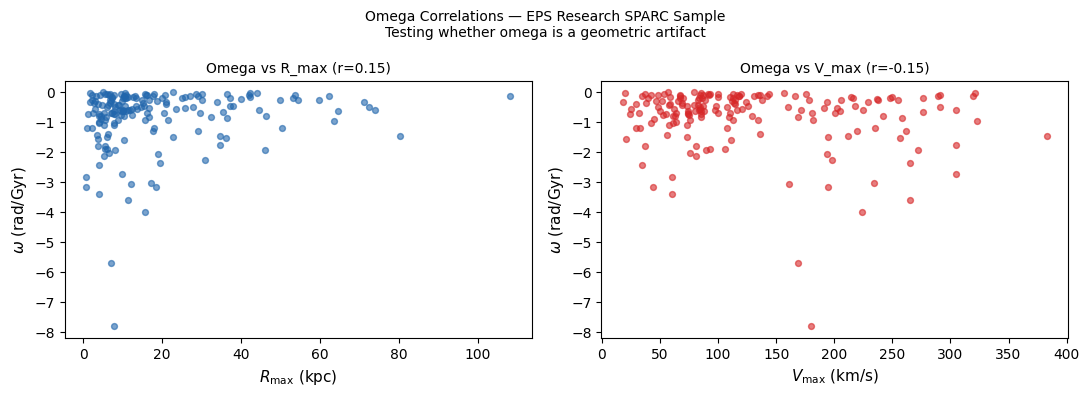

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(R_max, omegas, s=18, alpha=0.6, color='#2166ac')
axes[0].set_xlabel(r'$R_{\rm max}$ (kpc)', fontsize=11)
axes[0].set_ylabel(r'$\omega$ (rad/Gyr)', fontsize=11)
axes[0].set_title(f'Omega vs R_max (r={corr:.2f})', fontsize=10)

V_max  = [r['V_max']  for r in results]
corr2  = np.corrcoef(V_max, omegas)[0, 1]
axes[1].scatter(V_max, omegas, s=18, alpha=0.6, color='#d62728')
axes[1].set_xlabel(r'$V_{\rm max}$ (km/s)', fontsize=11)
axes[1].set_ylabel(r'$\omega$ (rad/Gyr)', fontsize=11)
axes[1].set_title(f'Omega vs V_max (r={corr2:.2f})', fontsize=10)

plt.suptitle('Omega Correlations — EPS Research SPARC Sample\n'
             'Testing whether omega is a geometric artifact', fontsize=10)
plt.tight_layout()
plt.savefig('ex18_omega_correlations.png', dpi=150, bbox_inches='tight')
plt.show()